# Chapter 4: Spatial SIR Model and Mass Conservation
**Supplementary Code for Dissertation Figures 4.6 & 4.7**

This notebook investigates the spatiotemporal dynamics of a stochastic SIR (Susceptible-Infected-Recovered) epidemic model on a 2D grid. Crucially, it highlights a theoretical limitation of the continuous spatial approximation: the Chemical Langevin Equation (CLE) violates mass conservation due to unbounded Gaussian noise, whereas the exact Gillespie Algorithm (SSA) strictly preserves the total population count.

In [1]:
# Environment Setup & Module Imports
import sys
import os
import time
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import seaborn as sns
import jsmfsb

# Route imports to the src folder
sys.path.append(os.path.abspath('..'))

%load_ext autoreload
%autoreload 2

# Academic Plotting
sns.set_theme(style='ticks')
plt.rcParams.update({'font.size': 11, 'font.family': 'serif'})

### Figure 4.6: Mass Conservation Violation
This block computes the total population ($S + I + R$) over time for both methods. Because the CLE relies on unbounded continuous noise (Brownian motion), population fractions can theoretically leak across the zero-bound, resulting in a gradual loss of total mass. The exact discrete SSA maintains strict integer conservation.

Initial S+I+R: 10005

Running SSA...
SSA done in 4.42s
Running CLE...
CLE done in 1.17s

SSA final total: 10005 (started 10005)
CLE final total: 25241 (started 10005)
CLE lost: -15236 (-152.3%)
CLE was 3.79x quicker but lost mass.


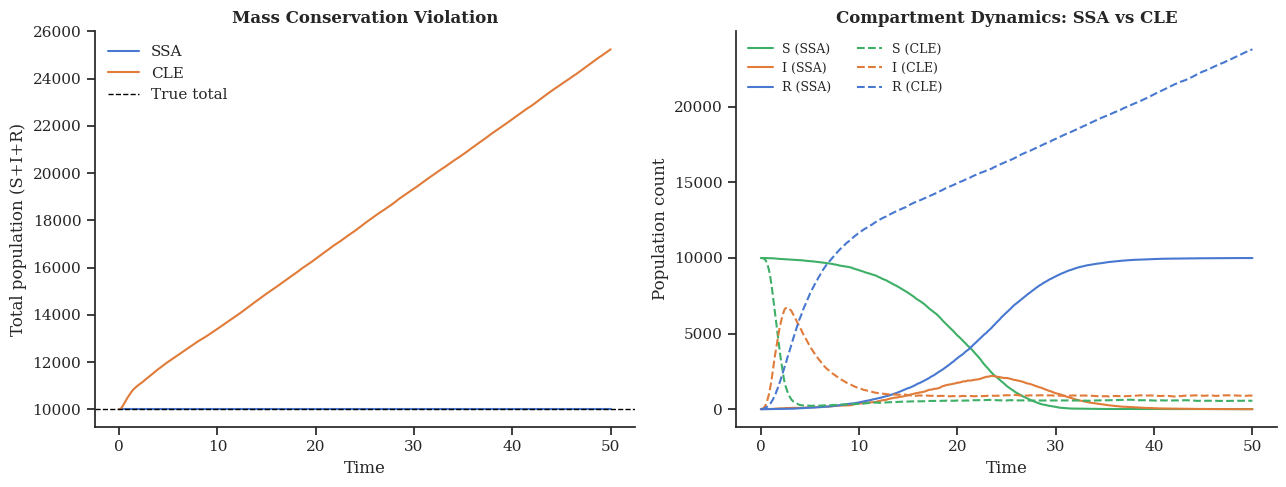

In [ ]:
# Mass Conservation Execution (Figure 4.6)

k0 = jax.random.key(34)

N = 30  
M = 30
T = 50
S = 10000
dt = 0.1

# --- Initial conditions ---
x0 = jnp.zeros((3, N, M))
sir = jsmfsb.models.sir(th=[0.3, 0.3])

num_boxes = N * M
flat_indices = jax.random.choice(k0, num_boxes, shape=(S,))
S_counts_flat = jnp.bincount(flat_indices, length=num_boxes)
S_counts_grid = S_counts_flat.reshape((N, M))

x0 = x0.at[0, :, :].set(S_counts_grid)
x0 = x0.at[1, N//2, M//2].set(5) # Initial infection seed in the centre
x0 = x0.at[2, :, :].set(0)

print(f"Initial S+I+R: {float(x0.sum()):.0f}")

# --- Step functions ---
d = jnp.array([0.1, 0.1, 0.1])
step_ssa = sir.step_gillespie_2d(d=d)
step_cle = sir.step_cle_2d(d=d)

# --- Run SSA ---
print("\nRunning SSA...", flush=True)
start = time.perf_counter()
out_ssa = jsmfsb.sim_time_series_2d(k0, x0, 0, T, dt, step_ssa, False)
out_ssa.block_until_ready()
time_ssa = time.perf_counter() - start
print(f"SSA done in {time_ssa:.2f}s")

# --- Run CLE ---
print("Running CLE...", flush=True)
start = time.perf_counter()
out_cle = jsmfsb.sim_time_series_2d(k0, x0, 0, T, dt, step_cle, False)
out_cle.block_until_ready()
time_cle = time.perf_counter() - start
print(f"CLE done in {time_cle:.2f}s")

# --- Compute totals over time ---
t_axis = jnp.linspace(0, T, out_ssa.shape[-1])

ssa_S = out_ssa[0].sum(axis=(0, 1))
ssa_I = out_ssa[1].sum(axis=(0, 1))
ssa_R = out_ssa[2].sum(axis=(0, 1))
ssa_total = ssa_S + ssa_I + ssa_R

cle_S = out_cle[0].sum(axis=(0, 1))
cle_I = out_cle[1].sum(axis=(0, 1))
cle_R = out_cle[2].sum(axis=(0, 1))
cle_total = cle_S + cle_I + cle_R

true_total = float(x0.sum())

print(f"\nSSA final total: {float(ssa_total[-1]):.0f} (started {true_total:.0f})")
print(f"CLE final total: {float(cle_total[-1]):.0f} (started {true_total:.0f})")
print(f"CLE lost: {true_total - float(cle_total[-1]):.0f} ({(true_total - float(cle_total[-1]))/true_total*100:.1f}%)")
print(f"CLE was {time_ssa/time_cle:.2f}x quicker")

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: mass conservation
axes[0].plot(t_axis, ssa_total, color='#4878CF', linewidth=1.5, label='SSA')
axes[0].plot(t_axis, cle_total, color='#E07B39', linewidth=1.5, label='CLE')
axes[0].axhline(y=true_total, color='black', linestyle='--', linewidth=1, label='True total')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Total population (S+I+R)')
axes[0].set_title('Mass Conservation Violation', fontweight='bold')
axes[0].legend(frameon=False)

# Right panel: CLE vs SSA compartments
axes[1].plot(t_axis, ssa_S, color='#3EAF67', linewidth=1.5, linestyle='-',  label='S (SSA)')
axes[1].plot(t_axis, ssa_I, color='#E07B39', linewidth=1.5, linestyle='-',  label='I (SSA)')
axes[1].plot(t_axis, ssa_R, color='#4878CF', linewidth=1.5, linestyle='-',  label='R (SSA)')
axes[1].plot(t_axis, cle_S, color='#3EAF67', linewidth=1.5, linestyle='--', label='S (CLE)')
axes[1].plot(t_axis, cle_I, color='#E07B39', linewidth=1.5, linestyle='--', label='I (CLE)')
axes[1].plot(t_axis, cle_R, color='#4878CF', linewidth=1.5, linestyle='--', label='R (CLE)')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Population count')
axes[1].set_title('Compartment Dynamics: SSA vs CLE', fontweight='bold')
axes[1].legend(frameon=False, fontsize=9, ncol=2)

sns.despine()
plt.tight_layout()
plt.savefig('../Dissertation_Figures/Fig4_6_SIR_Mass_Conservation.png', dpi=300, bbox_inches='tight')
plt.show()

### Figure 4.7: Spatial Heatmaps of the Infection Wave
Visualising the spread of the Infected (I) compartment over the $30 \times 30$ grid. The simulation is re-run with memory-efficient frame capturing to avoid storing the entire high-resolution trajectory in RAM.

Computing spatial frames...
Stepping t=0 -> t=5...
Stepping t=5 -> t=10...
Stepping t=10 -> t=15...
Stepping t=15 -> t=20...
Stepping t=20 -> t=25...
Stepping t=25 -> t=30...
Stepping t=30 -> t=35...
Stepping t=35 -> t=40...
Stepping t=40 -> t=45...
Stepping t=45 -> t=50...
Simulation complete. Proceeding to plotting.


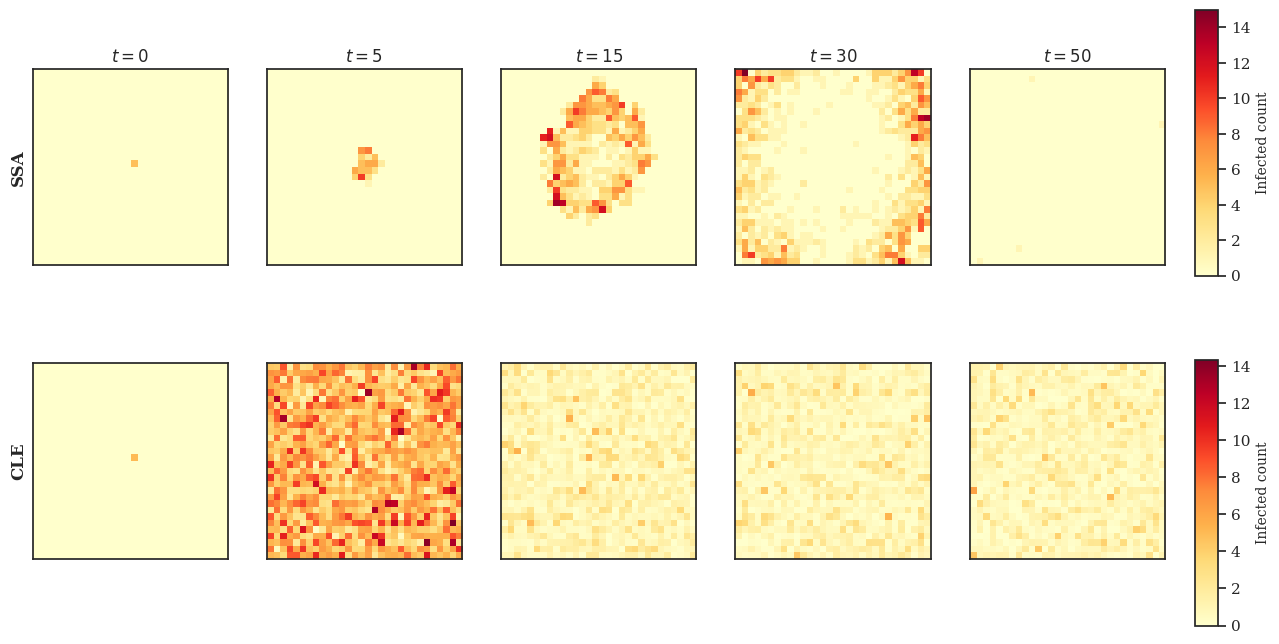

In [3]:
# Spatial Heatmaps Execution (Figure 4.7)

# Timepoints to visualise
plot_timepoints = [0, 5, 15, 30, 50]
compute_timepoints = list(range(0, 51, 5))
plot_indices = [compute_timepoints.index(t) for t in plot_timepoints]

# Re-run storing only specific frames to save RAM
ssa_frames, cle_frames = [], []
x_ssa, x_cle = x0, x0

keys_ssa = jax.random.split(k0, len(compute_timepoints))
# Use a slightly folded key for CLE to ensure independent noise streams
keys_cle = jax.random.split(jax.random.fold_in(k0, 1), len(compute_timepoints))

ssa_frames.append(x0)
cle_frames.append(x0)

t_current = 0
print("Computing spatial frames...", flush=True)
for i in range(1, len(compute_timepoints)):
    dt_step = compute_timepoints[i] - compute_timepoints[i-1]
    print(f"Stepping t={t_current} -> t={compute_timepoints[i]}...", flush=True)
    
    x_ssa = step_ssa(keys_ssa[i], x_ssa, t_current, dt_step)
    x_cle = step_cle(keys_cle[i], x_cle, t_current, dt_step)
    
    x_ssa.block_until_ready()
    x_cle.block_until_ready()
    
    ssa_frames.append(x_ssa)
    cle_frames.append(x_cle)
    t_current = compute_timepoints[i]

print("Simulation complete. Proceeding to plotting.")

# --- Plot infected ---
species_idx = 1  # I compartment

fig, axes = plt.subplots(2, len(plot_timepoints), figsize=(15, 7))
plt.subplots_adjust(right=0.88)

for row, (label, frames) in enumerate(zip(['SSA', 'CLE'], [ssa_frames, cle_frames])):
    row_vmax = max(float(frames[idx][species_idx].max()) for idx in plot_indices)

    for col, (idx, t) in enumerate(zip(plot_indices, plot_timepoints)):
        ax = axes[row, col]
        im = ax.imshow(frames[idx][species_idx], cmap='YlOrRd',
                       vmin=0, vmax=row_vmax, origin='lower')
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"$t = {t}$", fontsize=12)
        if col == 0:
            ax.set_ylabel(label, fontsize=12, fontweight='bold')

    cbar_ax = fig.add_axes([0.90, 0.55 - row * 0.5, 0.015, 0.38])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.set_label('Infected count', fontsize=10)

plt.savefig('../Dissertation_Figures/Fig4_7_SIR_Spatial_Snapshots.png', dpi=300, bbox_inches='tight')
plt.show()